**Introduction to Game Engines using Python**

*Activity 1:*

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,764 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,046 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:13 http://security.ubuntu.com/ubuntu

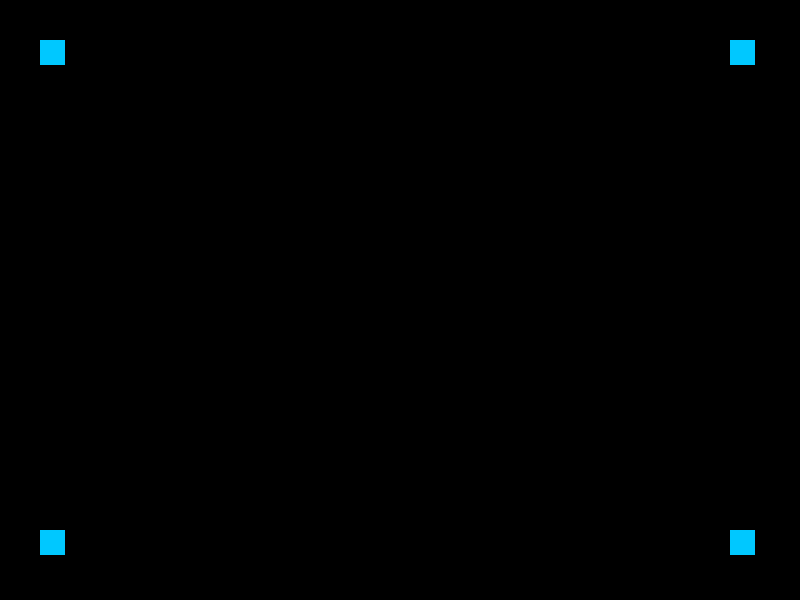

In [ ]:
!apt-get update
!apt-get install -y python3-pygame xvfb
!pip install pyvirtualdisplay
from pyvirtualdisplay import Display
import pygame
from pygame.locals import *
from IPython.display import Image, display
import os

# Start virtual display
virtual_display = Display(visible=0, size=(800, 600))
virtual_display.start()

# Initialize pygame
pygame.init()

# Create window
screen = pygame.display.set_mode((800, 600))
pygame.display.set_caption("Four Cyan Squares")

# Define Square class
class Square(pygame.sprite.Sprite):
    def __init__(self):
        super().__init__()
        self.surf = pygame.Surface((25, 25))
        self.surf.fill((0, 200, 255))
        self.rect = self.surf.get_rect()

# Create squares
square1 = Square()
square2 = Square()
square3 = Square()
square4 = Square()

# Black background
screen.fill((0, 0, 0))

# Draw squares
screen.blit(square1.surf, (40, 40))
screen.blit(square2.surf, (40, 530))
screen.blit(square3.surf, (730, 40))
screen.blit(square4.surf, (730, 530))

# Update display
pygame.display.flip()

# Save the screen as an image
pygame.image.save(screen, "output.png")

pygame.quit()
virtual_display.stop()

# Display the saved image
display(Image("output.png"))

*Activity 2:*

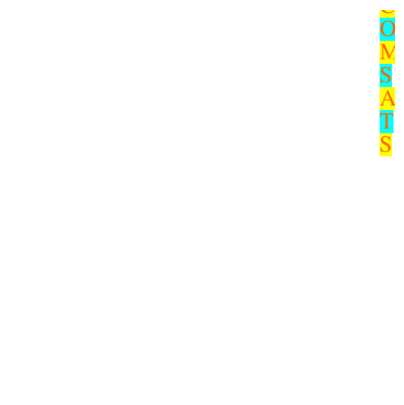

In [ ]:
# Install pygame and virtual display
!pip -q install pygame pyvirtualdisplay

from pyvirtualdisplay import Display
display = Display(visible=0, size=(500, 500))
display.start()

import pygame
import matplotlib.pyplot as plt

# Initialize pygame
pygame.init()

# Create window
WIDTH, HEIGHT = 500, 500
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Scrolling Text")

# Font
font = pygame.font.SysFont("Times New Roman", 30)

# Colors
WHITE = (255, 255, 255)
YELLOW = (255, 255, 0)
GREEN = (0, 255, 255)
ORANGE = (255, 100, 0)

# Create letter surfaces
letters = [
    font.render("C", True, ORANGE, YELLOW),
    font.render("O", True, ORANGE, GREEN),
    font.render("M", True, ORANGE, YELLOW),
    font.render("S", True, ORANGE, GREEN),
    font.render("A", True, ORANGE, YELLOW),
    font.render("T", True, ORANGE, GREEN),
    font.render("S", True, ORANGE, YELLOW),
]

i = 0
c = 1

# Run animation
for frame in range(36):

    if i >= 820:
        i = 0
        c += 1

    screen.fill(WHITE)

    if c % 6 == 1:       # Top
        y = 0
        x = -124 + i
        for letter in letters:
            screen.blit(letter, (x, y))
            x += 22

    elif c % 6 == 2:     # Bottom
        y = 470
        x = -124 + i
        for letter in letters:
            screen.blit(letter, (x, y))
            x += 22

    elif c % 6 == 3:     # Left
        x = 0
        y = -180 + i
        for letter in letters:
            screen.blit(letter, (x, y))
            y += 30

    elif c % 6 == 4:     # Right
        x = 480
        y = -180 + i
        for letter in letters:
            screen.blit(letter, (x, y))
            y += 30

    elif c % 6 == 5:     # Diagonal Left -> Right
        x = -162 + i
        y = -162 + i
        for letter in letters:
            screen.blit(letter, (x, y))
            x += 27
            y += 27

    else:                # Diagonal Right -> Left
        x = 662 - i
        y = -162 + i
        for letter in letters:
            screen.blit(letter, (x, y))
            x -= 27
            y += 27

    pygame.display.update()
    i += 80

# Show final frame
image = pygame.surfarray.array3d(screen)
image = image.swapaxes(0, 1)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.show()

pygame.quit()
display.stop()

*Graded Lab Task 1:*

In [ ]:
import pygame
import random
import sys
from pyvirtualdisplay import Display
from IPython.display import Image, display
import matplotlib.pyplot as plt

# Start virtual display
virtual_display = Display(visible=0, size=(600, 400))
virtual_display.start()

# Initialize Pygame
pygame.init()

# Screen dimensions
WIDTH = 600
HEIGHT = 400

# Colors
WHITE = (255, 255, 255)
GREEN = (0, 255, 0)
DARK_GREEN = (0, 155, 0)
RED = (255, 0, 0)
BLACK = (0, 0, 0)
YELLOW = (255, 255, 0) # Added Yellow color

# Create screen
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Snake Game")

# Clock
clock = pygame.time.Clock()

# Snake settings
snake_size = 20
snake_speed = 10

# Fonts
font = pygame.font.SysFont("Arial", 25)
game_font = pygame.font.SysFont("Arial", 40)


def show_score(score):
    text = font.render("Score: " + str(score), True, BLACK)
    screen.blit(text, (10, 10))


def draw_snake(snake_list):
    for block in snake_list:
        pygame.draw.rect(screen, GREEN, [block[0], block[1], snake_size, snake_size])


def message(msg, color):
    text = game_font.render(msg, True, color)
    screen.blit(text, (WIDTH // 6, HEIGHT // 3))


def game():
    game_over = False
    game_close = False

    x = WIDTH // 2
    y = HEIGHT // 2

    x_change = 0
    y_change = 0

    snake = []
    snake_length = 1

    food_x = random.randrange(0, WIDTH - snake_size, snake_size)
    food_y = random.randrange(0, HEIGHT - snake_size, snake_size)

    # Initialize yellow fruit position
    yellow_food_x = random.randrange(0, WIDTH - snake_size, snake_size)
    yellow_food_y = random.randrange(0, HEIGHT - snake_size, snake_size)

    # Create walls
    walls = [
        pygame.Rect(200, 100, 20, 120),
        pygame.Rect(350, 200, 20, 120),
        pygame.Rect(100, 300, 180, 20)
    ]

    try:
        while not game_over:

            while game_close:
                screen.fill(WHITE)
                message("Game Over! Press C to Play Again or Q to Quit", RED)
                show_score(snake_length - 1)
                pygame.display.update()

                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        game_over = True # Exit game loop
                        game_close = False # Exit inner loop
                        break # Break out of event loop

                    if event.type == pygame.KEYDOWN:
                        if event.key == pygame.K_q:
                            game_over = True # Exit game loop
                            game_close = False # Exit inner loop
                            break # Break out of event loop

                        if event.key == pygame.K_c:
                            game() # Restart game
                            return # Exit current game instance

                if game_over: # If a quit event occurred, break from the outer loop as well
                    break


            if game_over: # Check again after the game_close loop
                break

            for event in pygame.event.get():

                if event.type == pygame.QUIT:
                    game_over = True

                if event.type == pygame.KEYDOWN:

                    if event.key == pygame.K_LEFT:
                        x_change = -snake_size
                        y_change = 0

                    elif event.key == pygame.K_RIGHT:
                        x_change = snake_size
                        y_change = 0

                    elif event.key == pygame.K_UP:
                        y_change = -snake_size
                        x_change = 0

                    elif event.key == pygame.K_DOWN:
                        y_change = snake_size
                        x_change = 0

            if x >= WIDTH or x < 0 or y >= HEIGHT or y < 0:
                game_close = True

            x += x_change
            y += y_change

            screen.fill(WHITE)

            pygame.draw.rect(screen, RED, [food_x, food_y, snake_size, snake_size])

            snake_head = []
            snake_head.append(x)
            snake_head.append(y)
            snake.append(snake_head)

            if len(snake) > snake_length:
                del snake[0]

            for block in snake[:-1]:
                if block == snake_head:
                    game_close = True

            draw_snake(snake)

            # Check for collision with walls
            snake_rect = pygame.Rect(x, y, snake_size, snake_size)
            for wall in walls:
                pygame.draw.rect(screen, BLACK, wall) # Draw walls
                if snake_rect.colliderect(wall):
                    game_close = True

            # Increase snake speed after score > 100
            current_score = snake_length - 1
            if current_score > 100:
                snake_speed = 20
            else:
                snake_speed = 10

            # Draw yellow fruit after score > 150
            if current_score >= 150:
                pygame.draw.rect(screen, YELLOW, (yellow_food_x, yellow_food_y, snake_size, snake_size))

            show_score(current_score)

            pygame.display.update()

            if x == food_x and y == food_y:
                food_x = random.randrange(0, WIDTH - snake_size, snake_size)
                food_y = random.randrange(0, HEIGHT - snake_size, snake_size)
                snake_length += 1

            # Check collision with yellow fruit
            if current_score >= 150:
                if x == yellow_food_x and y == yellow_food_y:
                    snake_length += 2 # Yellow fruit gives 2 points
                    yellow_food_x = random.randrange(0, WIDTH - snake_size, snake_size)
                    yellow_food_y = random.randrange(0, HEIGHT - snake_size, snake_size)

            clock.tick(snake_speed)

    except KeyboardInterrupt: # Catch KeyboardInterrupt
        print("Game interrupted by user.")
    finally:
        # Capture and display a frame even if interrupted or game ends normally
        img_array = pygame.surfarray.array3d(screen)
        img_array = img_array.swapaxes(0, 1)
        plt.figure(figsize=(6, 4))
        plt.imshow(img_array)
        plt.axis('off')
        plt.title(f"Game Screen - Score: {snake_length - 1}")
        plt.show()

        pygame.quit()
        virtual_display.stop()
        sys.exit()

game()

Game interrupted by user.


*Graded Lab Task 2:*

In [7]:
import random

yellow_food_x = random.randrange(0, WIDTH - snake_size, snake_size)
yellow_food_y = random.randrange(0, HEIGHT - snake_size, snake_size)

# Create walls (place this before the game loop)
walls = [
    pygame.Rect(200, 100, 20, 120),
    pygame.Rect(350, 200, 20, 120),
    pygame.Rect(100, 300, 180, 20)
]

# --------------------------
# Place the following inside the game loop
# --------------------------

# Increase snake speed after score > 100
if snake_length - 1 > 100:
    snake_speed = 20
else:
    snake_speed = 10

# Draw walls
for wall in walls:
    pygame.draw.rect(screen, BLACK, wall)

# Check collision with walls
snake_rect = pygame.Rect(x, y, snake_size, snake_size)

for wall in walls:
    if snake_rect.colliderect(wall):
        game_close = True      # or game_over = True

# Draw yellow fruit after score > 150
if snake_length - 1 >= 150:
    pygame.draw.rect(
        screen,
        (255, 255, 0),
        (yellow_food_x, yellow_food_y, snake_size, snake_size)
    )

# Check collision with yellow fruit
if snake_length - 1 >= 150:
    if x == yellow_food_x and y == yellow_food_y:

        # Yellow fruit gives 2 points
        snake_length += 2

        # Generate another yellow fruit
        yellow_food_x = random.randrange(
            0, WIDTH - snake_size, snake_size
        )

        yellow_food_y = random.randrange(
            0, HEIGHT - snake_size, snake_size
        )

# Keep this at the end of your game loop
clock.tick(snake_speed)

NameError: name 'WIDTH' is not defined